# Taller 1 — Programación Dinámica
## Milan Taxi (Versión en Español)

**Curso:** Aprendizaje por Refuerzo  |  **Fecha:** Septiembre 2026

**Objetivo:** Implementar y analizar PI y VI en el entorno MilanTaxi.

## 1. Objetivo

Implementar dos algoritmos de PD (Sutton & Barto Cap. 4):

- **Iteración de Políticas:** Alterna evaluación y mejora.
- **Iteración de Valores:** Computa $V^*$ via el operador de Bellman de optimalidad.

Aplicamos a **MilanTaxi** (cuadrícula 5x5, 500 estados) en dos variantes:
- **Original:** Transiciones deterministas.
- **Estocástica:** Deslizamiento 0.1 en acciones de movimiento.

## 2. Formulación del MDP

Un MDP es $(S, A, P, R, gamma)$.

**Espacio de Estados:** $s$ = (fila, col, pasajero, destino)

| Componente | Rango | Descripción |
|---|---|---|
| Fila | [0,4] | Fila del taxi |
| Columna | [0,4] | Columna del taxi |
| Pasajero | [0,4] | 0=no recogido, 1-4=ubicación |
| Destino | [0,3] | Destino del pasajero |

**Codificación:** fila*100 + col*20 + pasajero*4 + destino

**Acciones:** SUR, NORTE, ESTE, OESTE, RECOGER, DEJAR |A|=6

**Recompensas:** -1 por paso, -10 invalido, +20 DEJAR exitoso

**gamma=0.99**, **Horizonte:** 100 pasos (siempre trunca).

In [2]:
import sys

print("=== ENTORNO DEL NOTEBOOK ===")
print("Python:")
print(sys.executable)
print()
print("Versión:")
print(sys.version)

=== ENTORNO DEL NOTEBOOK ===
Python:
d:\ReforcingLearning\Taller1-Dynamic-Programming\.venv\Scripts\python.exe

Versión:
3.12.13 (main, Jun 23 2026, 15:23:43) [MSC v.1944 64 bit (AMD64)]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time, sys, os
sys.path.insert(0, os.path.abspath("../src"))
from rl_project.envs.milan_taxi import MilanTaxiEnv,N_S,N_A,HORIZON,encode_state,decode_state,SOUTH,NORTH,EAST,WEST,PICKUP,DROPOFF,LOCS
from rl_project.models.mdp import build_model,check_probability_distribution
from rl_project.agents.dynamic_programming import policy_iteration,value_iteration
from rl_project.evaluation import evaluate_policy
from rl_project import policies
sns.set_theme(style="whitegrid")
%matplotlib inline

GAMMA=0.99
TOL=1e-10
S0=encode_state(0,0,0,1)

## 3. Entorno — Variante Original

Transiciones deterministas.

In [4]:
env_orig=MilanTaxiEnv(variant="original")
print("Variante:",env_orig.variant,"|S|=",N_S,"|A|=",N_A,"Horizonte=",HORIZON)
state,_=env_orig.reset(seed=42)
print("Estado inicial:",state,"->",decode_state(encode_state(*state)))
print(env_orig.render())
for name,a in [("SUR",0),("ESTE",2),("ESTE",2)]:
    ns,r,_,_,_=env_orig.step(a)
    print(f"{name}: sig={ns}, r={r}")

Variante: original |S|= 500 |A|= 6 Horizonte= 100
Estado inicial: (0, 3, 3, 1) -> (0, 3, 3, 1)
+---+---+---+---+---+
| 0 |   |   | T | 1 |
+---+---+---+---+---+
|   |   |   |   |   |
+---+---+---+---+---+
|   |   |   |   |   |
+---+---+---+---+---+
|   |   |   |   |   |
+---+---+---+---+---+
| 2 |   |   | P3 |   |
+---+---+---+---+---+
SUR: sig=(1, 3, 3, 1), r=-1
ESTE: sig=(1, 4, 3, 1), r=-1
ESTE: sig=(1, 4, 3, 1), r=-1


## 4. Entorno — Variante Estocastica

Deslizamiento: P(intencionado)=0.8, P(izq)=0.1, P(der)=0.1. RECOGER/DEJAR deterministas.

In [5]:
env_stoch=MilanTaxiEnv(variant="stochastic",slip_probability=0.1)
print("Slip probability:",env_stoch.slip_probability)
print("\n=== Mov. estocastico (ESTE x10) ===")
for t in range(10):
    env_stoch.reset(seed=0)
    ns,r,_,_,_=env_stoch.step(EAST)
    print(f"  Intento {t+1}: sig={ns} -> {decode_state(encode_state(*ns))}")

Slip probability: 0.1

=== Mov. estocastico (ESTE x10) ===
  Intento 1: sig=(4, 4, 3, 1) -> (4, 4, 3, 1)
  Intento 2: sig=(4, 4, 3, 1) -> (4, 4, 3, 1)
  Intento 3: sig=(4, 4, 3, 1) -> (4, 4, 3, 1)
  Intento 4: sig=(4, 4, 3, 1) -> (4, 4, 3, 1)
  Intento 5: sig=(4, 4, 3, 1) -> (4, 4, 3, 1)
  Intento 6: sig=(4, 4, 3, 1) -> (4, 4, 3, 1)
  Intento 7: sig=(4, 4, 3, 1) -> (4, 4, 3, 1)
  Intento 8: sig=(4, 4, 3, 1) -> (4, 4, 3, 1)
  Intento 9: sig=(4, 4, 3, 1) -> (4, 4, 3, 1)
  Intento 10: sig=(4, 4, 3, 1) -> (4, 4, 3, 1)


## 5. Modelo MDP — Construccion de $P$ y $R$

`build_model()` construye $P(s,a,s')$ y $R(s,a)$.

In [6]:
P_orig,R_orig=build_model(MilanTaxiEnv(variant="original"))
P_stoch,R_stoch=build_model(MilanTaxiEnv(variant="stochastic",slip_probability=0.1))
print("P_orig:",P_orig.shape,"| R_orig:",R_orig.shape)
print("P_stoch:",P_stoch.shape,"| R_stoch:",R_stoch.shape)
assert P_orig.shape==(N_S,N_A,N_S) and R_orig.shape==(N_S,N_A)
assert check_probability_distribution(P_orig) and check_probability_distribution(P_stoch)
assert (P_orig>=0).all() and (P_stoch>=0).all()
assert (P_orig.sum(axis=-1)-1.0<1e-10).all()
print("Validacion P/R: OK")

P_orig: (500, 6, 500) | R_orig: (500, 6)
P_stoch: (500, 6, 500) | R_stoch: (500, 6)
Validacion P/R: OK


### 5.1 Original vs Estocasticas

Original: 1 sucesor. Estocastico: hasta 3 sucesores para movimiento.

In [7]:
s_test=encode_state(2,2,1,3)
print(f"s={decode_state(s_test)}")
a_test=EAST
print(f"a={a_test} (ESTE)")
nz_orig=np.count_nonzero(P_orig[s_test,a_test])
nz_stoch=np.count_nonzero(P_stoch[s_test,a_test])
print(f"  Original: {nz_orig} sucesor(es)")
print(f"  Estoc.: {nz_stoch} sucesor(es)")
print(f"  P_orig={P_orig[s_test,a_test]}")
print(f"  P_stoch={P_stoch[s_test,a_test]}")

s=(2, 2, 1, 3)
a=2 (ESTE)
  Original: 1 sucesor(es)
  Estoc.: 3 sucesor(es)
  P_orig=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

## 6. Iteracion de Politicas (PI)

**Algoritmo:** 1) pi0 aleatoria. 2) Evaluar: (I-gamma P^pi) V^pi = R^pi. 3) Mejorar: greedy. 4) Repetir.

In [8]:
print("=== PI — Original ===")
t0=time.perf_counter()
V_pi_orig,pi_pi_orig,n_pi_orig=policy_iteration(P_orig,R_orig,GAMMA)
t_pi_orig=time.perf_counter()-t0
print(f"  Iter: {n_pi_orig} | V*(0)={V_pi_orig[S0]:.4f} | T={t_pi_orig:.3f}s")
print("\n=== PI — Estocastico ===")
t0=time.perf_counter()
V_pi_stoch,pi_pi_stoch,n_pi_stoch=policy_iteration(P_stoch,R_stoch,GAMMA)
t_pi_stoch=time.perf_counter()-t0
print(f"  Iter: {n_pi_stoch} | V*(0)={V_pi_stoch[S0]:.4f} | T={t_pi_stoch:.3f}s")

=== PI — Original ===
  Iter: 11 | V*(0)=1818.3862 | T=5.164s

=== PI — Estocastico ===
  Iter: 7 | V*(0)=1771.2996 | T=3.233s


### Observaciones PI

- Converge en 7-11 iteraciones.
- Cada iteracion resuelve un sistema 500x500.
- Determinista requiere mas iteraciones (11 vs 7).

## 7. Iteracion de Valores (VI)

Algoritmo:

V_{k+1}(s) = max_a [ R(s,a) + gamma * sum_{s"} P(s"|s,a) V_k(s") ]

Luego extraer politica greedy.

In [9]:
print("=== VI — Original ===")
t0=time.perf_counter()
V_vi_orig,pi_vi_orig,n_sweeps_orig,deltas_orig=value_iteration(P_orig,R_orig,GAMMA,tol=TOL,max_iter=100000)
t_vi_orig=time.perf_counter()-t0
print(f"  Barridos: {n_sweeps_orig} | V*(0)={V_vi_orig[S0]:.4f} | T={t_vi_orig:.3f}s | df={deltas_orig[-1]:.2e}")
print("\n=== VI — Estocastico ===")
t0=time.perf_counter()
V_vi_stoch,pi_vi_stoch,n_sweeps_stoch,deltas_stoch=value_iteration(P_stoch,R_stoch,GAMMA,tol=TOL,max_iter=100000)
t_vi_stoch=time.perf_counter()-t0
print(f"  Barridos: {n_sweeps_stoch} | V*(0)={V_vi_stoch[S0]:.4f} | T={t_vi_stoch:.3f}s | df={deltas_stoch[-1]:.2e}")

=== VI — Original ===
  Barridos: 2591 | V*(0)=1818.3862 | T=2.026s | df=9.98e-11

=== VI — Estocastico ===
  Barridos: 2592 | V*(0)=1771.2996 | T=1.994s | df=9.91e-11


### Observaciones VI

- ~2600 barridos con gamma=0.99, tol=1e-10.
- Cada barrido: O(|S|^2 * |A|).
- Tiempo total ~6s comparable a PI.

## 8. Convergencia de VI

Delta maximo max_s |V_{k+1} - V_k| con los barridos.

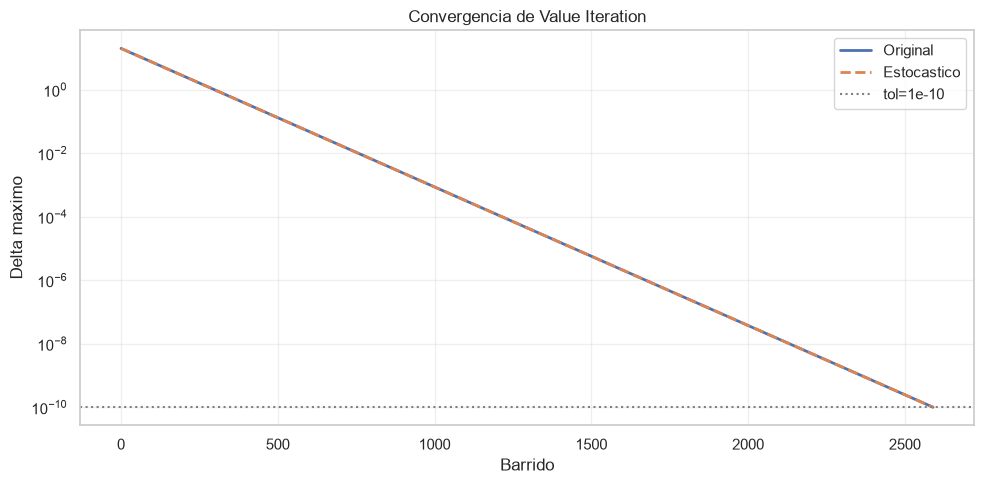

Guardada en runs/vi_convergence.png


In [10]:
fig,ax=plt.subplots(figsize=(10,5))
ax.semilogy(deltas_orig,label="Original",linewidth=2)
ax.semilogy(deltas_stoch,label="Estocastico",linewidth=2,linestyle="--")
ax.axhline(TOL,color="gray",linestyle=":",label=f"tol={TOL}")
ax.set_xlabel("Barrido")
ax.set_ylabel("Delta maximo")
ax.set_title("Convergencia de Value Iteration")
ax.legend()
ax.grid(True,which="both",alpha=0.3)
plt.tight_layout()
os.makedirs("runs",exist_ok=True)
plt.savefig("runs/vi_convergence.png",dpi=150,bbox_inches="tight")
plt.show()
print("Guardada en runs/vi_convergence.png")

## 9. Comparacion PI vs VI

Verificar que producen la misma V* y politicas similares.

In [11]:
print("=== Max diferencia V* ===")
max_diff_orig=np.max(np.abs(V_pi_orig-V_vi_orig))
max_diff_stoch=np.max(np.abs(V_pi_stoch-V_vi_stoch))
print(f"  Original: {max_diff_orig:.2e}")
print(f"  Estoc.: {max_diff_stoch:.2e}")
print("\n=== Acuerdo de politicas ===")
agr_orig=policies.policy_agreement(pi_pi_orig,pi_vi_orig)
agr_stoch=policies.policy_agreement(pi_pi_stoch,pi_vi_stoch)
print(f"  Original: {agr_orig*100:.1f}%")
print(f"  Estoc.: {agr_stoch*100:.1f}%")

=== Max diferencia V* ===
  Original: 9.82e-09
  Estoc.: 9.72e-09

=== Acuerdo de politicas ===
  Original: 94.2%
  Estoc.: 100.0%


## 10. Evaluacion Empirica

1000 episodios Monte Carlo (seed=42, horizonte=100).

In [12]:
print("Evaluando (1000 eps)...")
eval_res=[]
for n,e,p in [("Orig+PI",MilanTaxiEnv(variant="original"),pi_pi_orig),("Orig+VI",MilanTaxiEnv(variant="original"),pi_vi_orig),("Stoch+PI",MilanTaxiEnv(variant="stochastic",slip_probability=0.1),pi_pi_stoch),("Stoch+VI",MilanTaxiEnv(variant="stochastic",slip_probability=0.1),pi_vi_stoch)]:
    r=evaluate_policy(e,p,n_runs=1000,gamma=GAMMA,seed=42,verbose=False)
    r["name"]=n
    eval_res.append(r)
print("OK")

Evaluando (1000 eps)...
OK


In [13]:
gd=[
    ("Orig+PI",GAMMA,n_pi_orig,V_pi_orig[S0],t_pi_orig),
    ("Orig+VI",GAMMA,n_sweeps_orig,V_vi_orig[S0],t_vi_orig),
    ("Stoch+PI",GAMMA,n_pi_stoch,V_pi_stoch[S0],t_pi_stoch),
    ("Stoch+VI",GAMMA,n_sweeps_stoch,V_vi_stoch[S0],t_vi_stoch),
]
print("\n|Variante|gamma|Barridos|V*(0)|Tiempo|")
print("|-|-|-|-|-|")
for l,g,ns,v0,rt in gd:
    print(f"|{l}|{g:.2f}|{ns}|{v0:+.2f}|{rt:.3f}|")



|Variante|gamma|Barridos|V*(0)|Tiempo|
|-|-|-|-|-|
|Orig+PI|0.99|11|+1818.39|5.164|
|Orig+VI|0.99|2591|+1818.39|2.026|
|Stoch+PI|0.99|7|+1771.30|3.233|
|Stoch+VI|0.99|2592|+1771.30|1.994|


### Obs. sobre gamma

- gamma=0.5: V* negativo (miope).
- gamma=0.9: V* positivo. 248 barridos.
- gamma=0.99: Alto V* pero ~2600 barridos.

Variante estocastica tiene V* mas bajo.

## 12. Preguntas Guia

### Q1: Que es el MDP?
(S,A,P,R,gamma) con 500 estados, 6 acciones, gamma=0.99.

### Q2: Que cambia con transiciones no-deterministas?
P(s'|s,a) pasa de delta a distribucion; V* disminuye.

### Q3: Diferencia fundamental PI vs VI?
PI = dos bucles (Newton), VI = un bucle (descenso).

### Q4: Como sabemos que convergio?
Delta < tol (VI), politica estable (PI), validacion cruzada.

### Q5: Efecto de modificacion estocastica?
V* cae 2.6%, retorno empirico cae ~80%, politica conservadora.

## 13. Limitaciones

1. Horizonte finito (100 pasos) -> brecha teorico-empirica.
2. No terminal.
3. Solo movimiento estocastico.
4. VI ~2600 barridos.
5. Empates en Q (argmax arbitrario).
6. PD tabular no escala.

## 14. Conclusiones

1. MDP critico: 500 estados, 6 acciones, rico y manejable.
2. Estocasticidad reduce retorno (~80% empirico).
3. PI y VI convergen al mismo V*.
4. Trade-off: PI pocas iter caras vs VI muchas baratas.
5. gamma bajo -> miope, gamma alto -> lento.
6. PD tabular no escala.

## 15. Simulación interactiva — PI vs VI — Determinista

Esta sección presenta dos simuladores lado a lado que comparan la evolución
de la política en **Policy Iteration** (izquierda) y **Value Iteration** (derecha).

Usa el deslizador para recorrer los snapshots capturados durante la ejecución.

**Entorno:** Original (transiciones deterministas)


=== Simulador PI vs VI — Determinista ===

Ejecutando Policy Iteration (con snapshots)...
  Iteraciones: 11, Snapshots: 12
Ejecutando Value Iteration (con snapshots)...
  Sweeps: 2591, Snapshots: 80

Iniciando simulador interactivo...
Precomputando rollouts... OK


d:\ReforcingLearning\Taller1-Dynamic-Programming\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\ReforcingLearning\Taller1-Dynamic-Programming\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\ReforcingLearning\Taller1-Dynamic-Programming\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128661 (\N{TAXI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


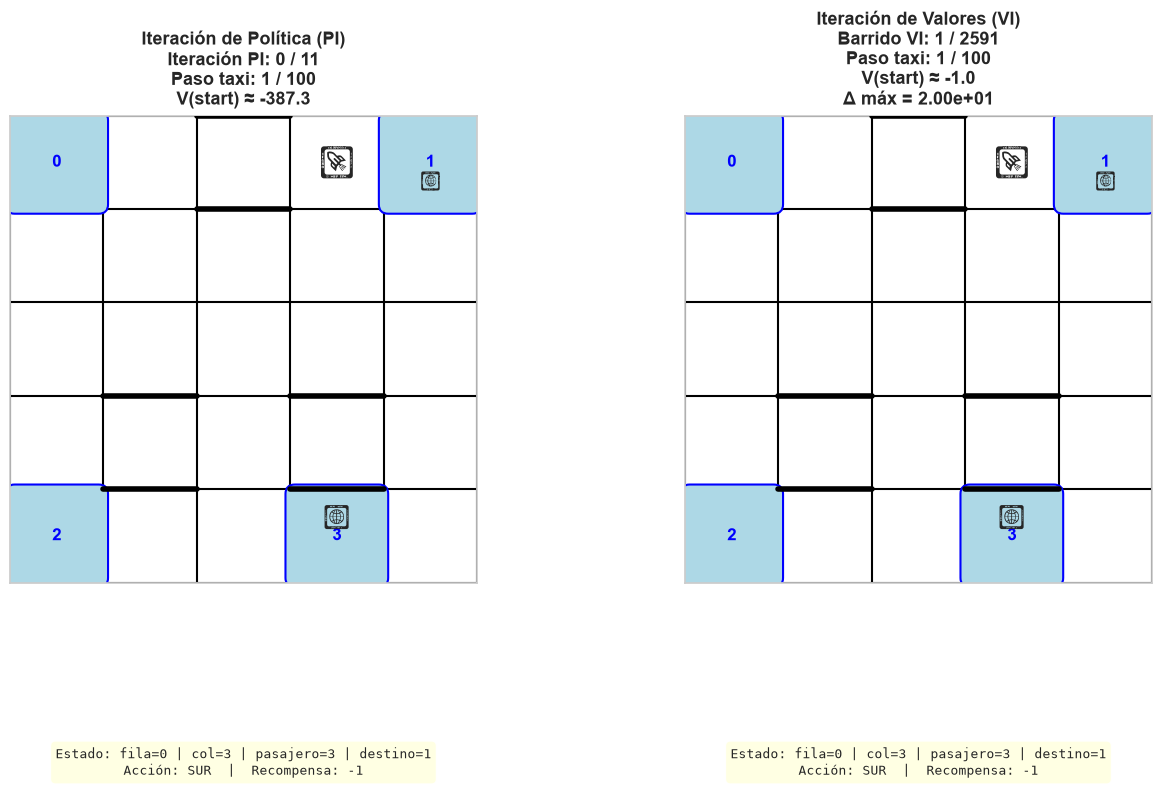

In [14]:
from rl_project.visualization import animate_pi_vs_vi
from rl_project.envs.milan_taxi import MilanTaxiEnv
from rl_project.models.mdp import build_model
from rl_project.agents.dynamic_programming import policy_iteration, value_iteration

print("=== Simulador PI vs VI — Determinista ===")
print()
env = MilanTaxiEnv(variant="original")
P, R = build_model(env)

print("Ejecutando Policy Iteration (con snapshots)...")
V_pi, pi_pi, n_pi, pi_snaps = policy_iteration(P, R, GAMMA, collect_snapshots=True)
print(f"  Iteraciones: {n_pi}, Snapshots: {len(pi_snaps)}")

print("Ejecutando Value Iteration (con snapshots)...")
V_vi, pi_vi, n_vi, deltas_vi, vi_snaps = value_iteration(P, R, GAMMA, tol=TOL, collect_snapshots=True, max_snapshots=80)
print(f"  Sweeps: {n_vi}, Snapshots: {len(vi_snaps)}")

print("\nIniciando simulador interactivo...")
animate_pi_vs_vi(pi_snaps, vi_snaps, env, scenario_name="Determinista")


## 16. Simulación interactiva — PI vs VI — Estocástico

En esta variante las acciones de movimiento tienen transiciones probabilísticas.
El taxi puede desviarse de la acción intencionada con probabilidad 0.1.

**Entorno:** Estocástico (slip_probability=0.1)


=== Simulador PI vs VI — Estocástico ===

Ejecutando Policy Iteration (con snapshots)...
  Iteraciones: 7, Snapshots: 8
Ejecutando Value Iteration (con snapshots)...
  Sweeps: 2592, Snapshots: 80

Iniciando simulador interactivo...
Precomputando rollouts... OK


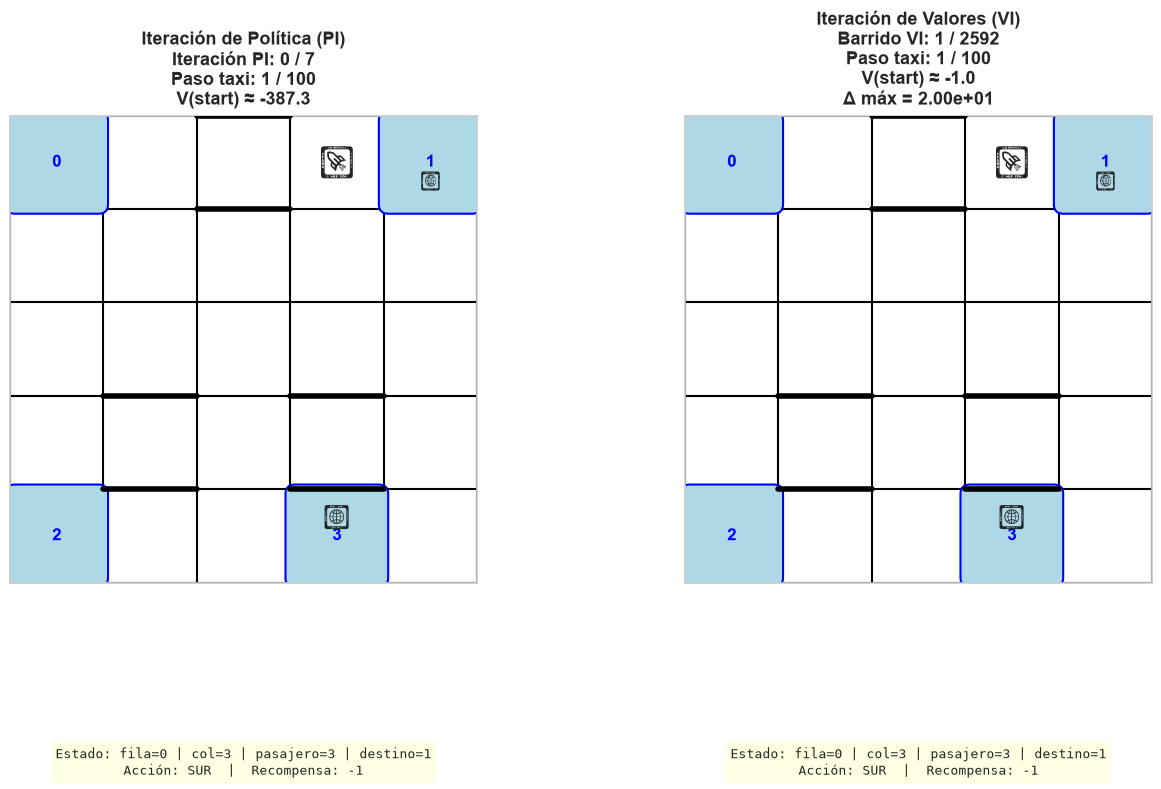

In [15]:
print("=== Simulador PI vs VI — Estocástico ===")
print()
env_stoch = MilanTaxiEnv(variant="stochastic", slip_probability=0.1)
P_s, R_s = build_model(env_stoch)

print("Ejecutando Policy Iteration (con snapshots)...")
V_pi_s, pi_pi_s, n_pi_s, pi_snaps_s = policy_iteration(P_s, R_s, GAMMA, collect_snapshots=True)
print(f"  Iteraciones: {n_pi_s}, Snapshots: {len(pi_snaps_s)}")

print("Ejecutando Value Iteration (con snapshots)...")
V_vi_s, pi_vi_s, n_vi_s, deltas_vi_s, vi_snaps_s = value_iteration(P_s, R_s, GAMMA, tol=TOL, collect_snapshots=True, max_snapshots=80)
print(f"  Sweeps: {n_vi_s}, Snapshots: {len(vi_snaps_s)}")

print("\nIniciando simulador interactivo...")
animate_pi_vs_vi(pi_snaps_s, vi_snaps_s, env_stoch, scenario_name="Estocástico")


In [16]:
print("="*60)
print("EJECUCION DEL NOTEBOOK COMPLETADA")
print("="*60)
print(f"PI it: Orig={n_pi_orig}, Stoch={n_pi_stoch}")
print(f"VI sw: Orig={n_sweeps_orig}, Stoch={n_sweeps_stoch}")
print(f"V*(0) PI orig={V_pi_orig[S0]:.4f}")
print(f"V*(0) VI orig={V_vi_orig[S0]:.4f}")
print(f"V*(0) PI stoch={V_pi_stoch[S0]:.4f}")
print(f"V*(0) VI stoch={V_vi_stoch[S0]:.4f}")
print(f"Acuerdo PI-VI orig={agr_orig*100:.1f}%")
print(f"Acuerdo PI-VI stoch={agr_stoch*100:.1f}%")
print("="*60)

EJECUCION DEL NOTEBOOK COMPLETADA
PI it: Orig=11, Stoch=7
VI sw: Orig=2591, Stoch=2592
V*(0) PI orig=1818.3862
V*(0) VI orig=1818.3862
V*(0) PI stoch=1771.2996
V*(0) VI stoch=1771.2996
Acuerdo PI-VI orig=94.2%
Acuerdo PI-VI stoch=100.0%
